# XGBoost Global Interpretation
- Notebook completed by Adam Lang
- This is from the train in data course by Soledad Galli, PhD, which I highly recommend taking to enhance your ML explainability skills.
- Date: 8-21-2026

## Imports

In [1]:
## imports
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd

## sklearn imports
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split ## train-test split

## xgboost model
from xgboost import XGBRegressor

## Load Dataset

In [2]:
## load california housing price prediction dataset from sklearn
X, y = fetch_california_housing(return_X_y=True, as_frame=True)
X = X.drop(columns=["Latitude", "Longitude"]) ## drop features we dont need

## view top 5 rows
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467


## Visualize Dataset

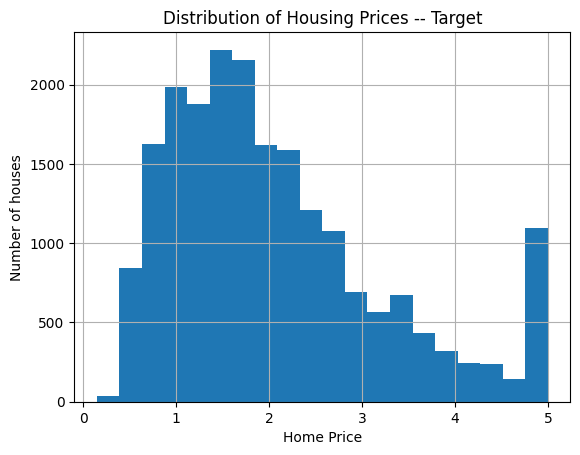

In [3]:
## view target distribution
y.hist(bins=20)
plt.xlabel("Home Price")
plt.ylabel("Number of houses")
plt.title("Distribution of Housing Prices -- Target")
plt.show();

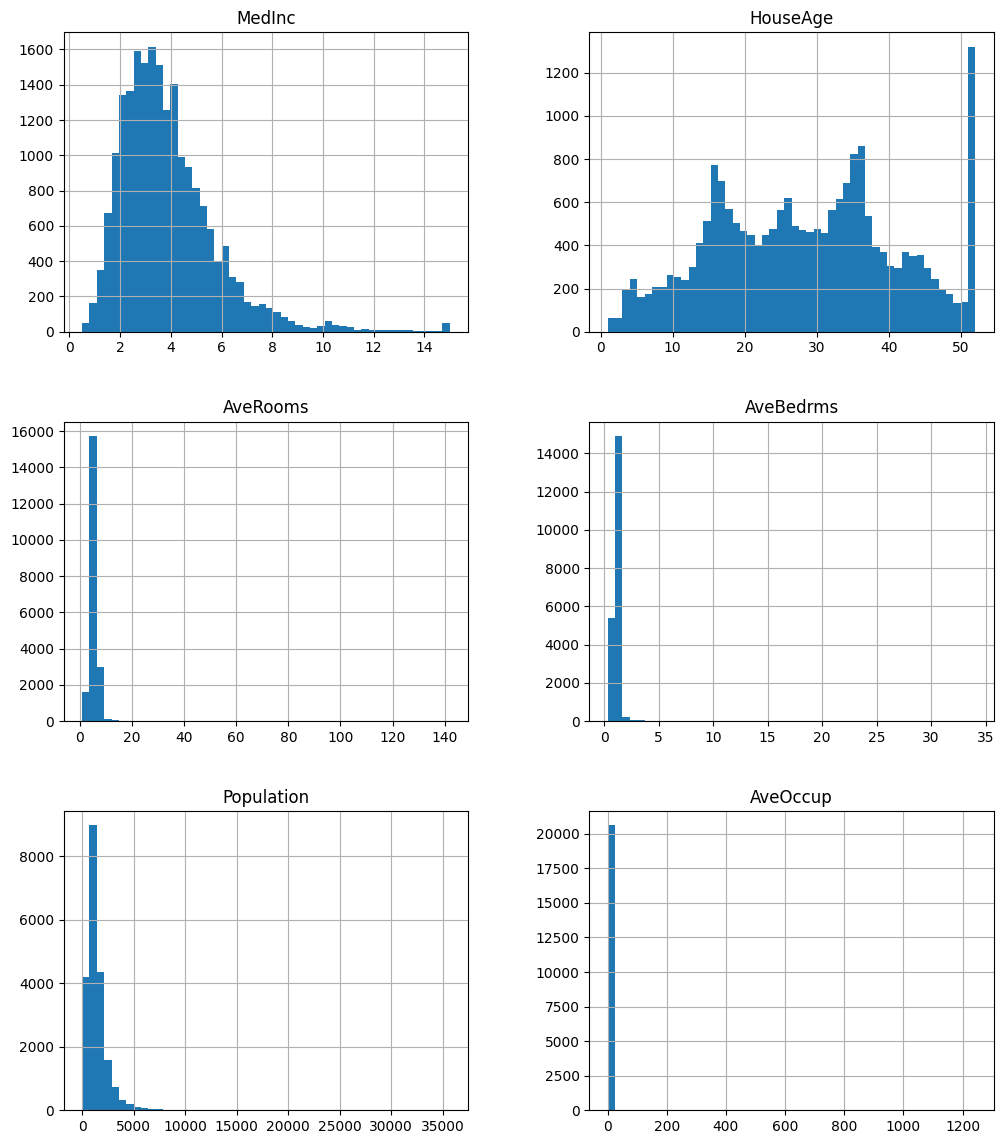

In [4]:
## display variables distribution
X.hist(bins=50, figsize=(12,14))
plt.show();

## Train-Test-Split

In [5]:
## train-test split for model train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)


## shape
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (14448, 6)
X_test shape: (6192, 6)


## XGBoost - Fit model

In [6]:
## fit model
gbm = XGBRegressor(
    importance_type="gain", ## feature importance uses GAIN -- sum of squares
    n_estimators=50,
    max_depth=3,
    random_state=3,
)

## fit model
gbm.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type='gain', interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=50,
             n_jobs=None, num_parallel_tree=None, ...)

In [7]:
## R2 in train set
gbm.score(X_train, y_train)

0.7167278929526246

In [8]:
## R2 in test set
gbm.score(X_test, y_test)

0.677704385919577

## Summary
- The model explains more than 60% of the variability in the target variable -- not so great.

## Global Interpretability -- Feature Importance
- See this excellent resource: https://zg104.github.io/ML/XGBoost.html#how-can-you-interpret-the-output-of-an-xgboost-model-in-terms-of-feature-importance
- In short, XGBoost uses the avg gain of each feature across all tree splits. Higher gain indicates more important features.

In [9]:
## feature importance
global_exp = pd.Series(gbm.feature_importances_, index=gbm.feature_names_in_)
global_exp

,0
MedInc,0.627121
HouseAge,0.081388
AveRooms,0.069338
AveBedrms,0.024031
Population,0.019749
AveOccup,0.178373


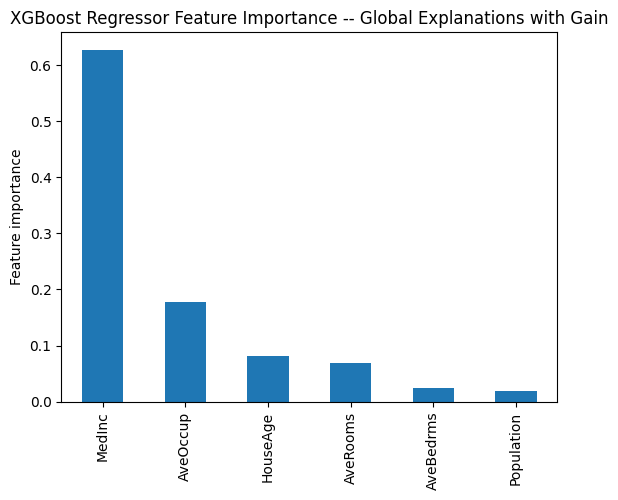

In [11]:
## plot explainability
global_exp.sort_values(ascending=False).plot.bar()
plt.ylabel("Feature importance")
plt.title("XGBoost Regressor Feature Importance -- Global Explanations with Gain")
plt.show();

## Summary
- The feature importance is relatively the same as using the GBM Regressor from sklearn as XGBoostRegressor is virtually the same model.
- Median income is the most important feature and Population is the least.

## Compare results using different Feature Importance Calculation -- WEIGHT
- Here we will use "weight" instead of "gain".
- In XGBoost, weight feature importance counts the total number of times a specific feature is used to split data across all trees in the model.
  - It measures feature frequency, whereas gain measures the average training loss reduction (or error reduction) brought by a feature whenever it splits a node.
- A simple comparison of the two methods for calculating feature importances in XGBoost:

1. Gain: Based on the training error reduced by each split in all trees. More closely related to how individual trees operate.

2. Weight: Based on the number of times a feature is chosen in all the trees. More suitable for comparing feature importance across multiple models.

- [source](https://medium.com/@coderhack.com/xgboost-feature-importance-gain-vs-weight-intution-behind-it-25e11380c18f)

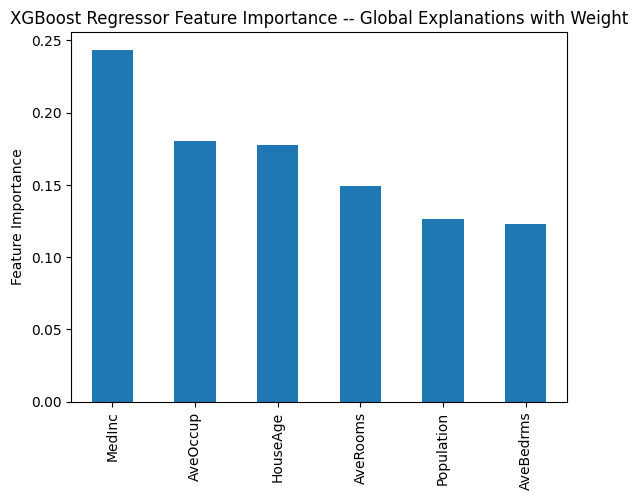

In [12]:
## fit the XGBRegressor with "weight"
gbm = XGBRegressor(
    importance_type="weight", ## weight instead of gain
    n_estimators=50,
    max_depth=3,
    random_state=3,
)
## fit model
gbm.fit(X_train,y_train)

## view features
global_exp = pd.Series(gbm.feature_importances_, index=gbm.feature_names_in_)
global_exp.sort_values(ascending=False).plot.bar()
plt.ylabel("Feature Importance")
plt.title("XGBoost Regressor Feature Importance -- Global Explanations with Weight")
plt.show();

## Summary
- We can see the differnce in Weight from gain above.
- The distribution is spread more evenly because all Weight is doing here is counting the number of nodes that chose that feature across the trees.

## Compare results using different Feature Importance Calculation -- COVER
- Here we can use "Cover" instead. Cover is the average number of training samples (observations) that pass through splits using that feature. The major bias here is that it does not reflect how much the feature actually improves the predictions.

- The core difference lies in what each metric measures:
  - gain calculates prediction power (loss reduction)
  - weight counts splitting frequency,
  - cover measures data volume affected

- For general interpretation and feature selection, gain is the most reliable metric because it directly reflects a feature's contribution to improving the model's accuracy.
- [source](https://machinelearningmastery.com/how-to-interpret-your-xgboost-model-a-practical-guide-to-feature-importance/)

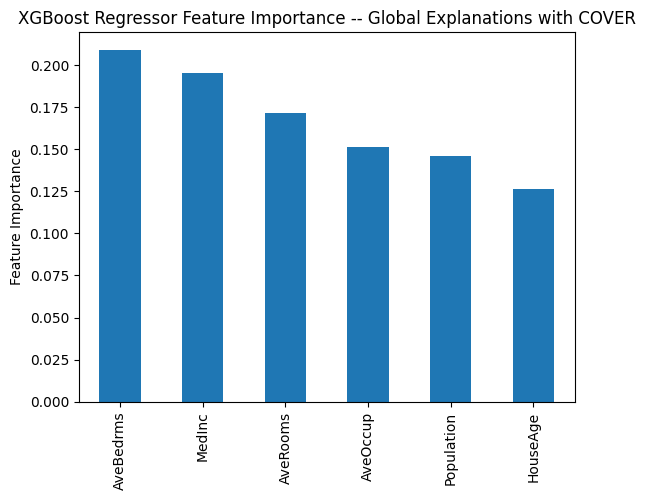

In [13]:
## 3rd example using "cover"
gbm = XGBRegressor(
    importance_type="cover",
    n_estimators=50,
    max_depth=3,
    random_state=3,
)
## fit new model
gbm.fit(X_train, y_train)

## plot results
global_exp = pd.Series(gbm.feature_importances_, index=gbm.feature_names_in_)
global_exp.sort_values(ascending=False).plot.bar()
plt.ylabel("Feature Importance")
plt.title("XGBoost Regressor Feature Importance -- Global Explanations with COVER")
plt.show();

## Summary
- We can see there is even more balanced importance of each feature now with COVER.
- So in summary:
  - Gain is very similar to importance values seen in the GBM regressor in sklearn.
  - Weight is just the number of times a feature was selected at each node (its a frequency count)
  - Cover is simply the number of samples split at each node where the feature was used.